In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 



In [1]:
precision=1e-10

In [167]:
output_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS5000'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, '/outs/filtered_peak_bc_matrix/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')


In [168]:
tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [169]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])

In [170]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [171]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')

In [172]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy
AAACAAGCAAACATGT-1,4,1.0,25.000000,4,1.0,25.000000,NaN
AAACAAGCAAACCAGC-1,1,1.0,100.000000,1,1.0,100.000000,0.000342
AAACAAGCAAACCTAG-1,207,17.0,8.212560,207,16.0,7.729469,0.006343
AAACAAGCAAACTAAC-1,1,0.0,0.000000,1,0.0,0.000000,NaN
AAACAAGCAAAGAAGC-1,987,48.0,4.863222,987,43.0,4.356636,0.015458


## Load CR's barcodes info 

In [173]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [174]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)

# See Tn5 insersion frequency distribution at different entropy levels

## For real cells 

In [175]:
all_df_cr = all_df.loc[~all_df['Cluster'].isna()].copy()

In [177]:
cr_bcs = all_df_cr.index.tolist()
Ncr_bcs = len(cr_bcs)
print(f'Number of cell barcodes: {Ncr_bcs}')

Number of cell barcodes: 1959


In [198]:
np.random.seed(4)
sample_bc = np.random.choice(cr_bcs, size=1, replace=False)

all_df_cr.loc[sample_bc]

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy,Cluster,log(total_fragments),log(entropy)
GCTTAGCTCGGCTATC-1,15932,10799.0,67.781823,15932,10325.0,64.806678,0.20147,2.0,4.20227,-0.695789


In [199]:
bc_insert_freq = tn5_insert_freq[sample_bc[0]].toarray()
bc_seq_depth = all_df_cr.loc[sample_bc, 'total_fragments_peaks'].iloc[0]
bc_logentropy_val = all_df_cr.loc[sample_bc, 'log(entropy)'].iloc[0]
bc_frag_overlap = all_df_cr.loc[sample_bc, 'frag_overlap_entropy_peaks%'].iloc[0]

np.unique(bc_insert_freq, return_counts=True),  print(f"seq-depth: {bc_seq_depth}. log(entropy): {bc_logentropy_val}. frag-overlap: {bc_frag_overlap}")

seq-depth: 15932. log(entropy): -0.6957885681046683. frag-overlap: 67.78182274667336


((array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 12], dtype=int32),
  array([48571,    60,   866,    15,   186,     4,    67,     1,    18,
             3,     1])),
 None)

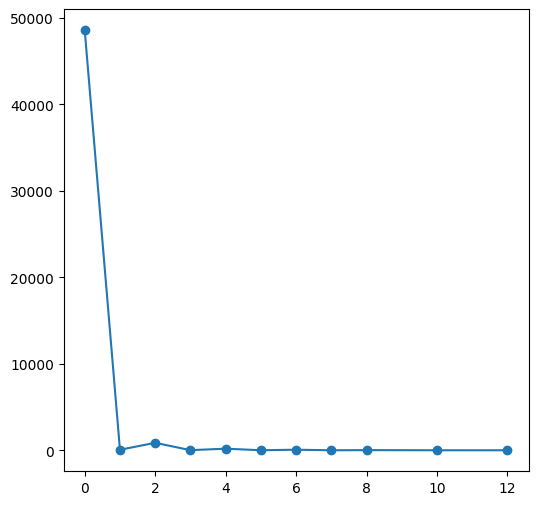

In [200]:
val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.plot(val, freq, marker='o' )#, marker='0', linestyle='None')

## For bad-quality cell or empty barcodes 

In [184]:
depth_threshold = 1000
all_df_empty = all_df.loc[all_df['Cluster'].isna() & (all_df['total_fragments_peaks'] > depth_threshold)].copy()
len(all_df_empty)

1622

In [185]:
cr_empties = all_df_empty.index.tolist()


In [186]:
np.random.seed(6)
sample_empty = np.random.choice(cr_empties, size=1, replace=False)

all_df_empty.loc[sample_empty]

sample_empty[0] in tn5_insert_freq.keys()

True

In [187]:
empty_insert_freq = tn5_insert_freq[sample_empty[0]].toarray()
empty_seq_depth = all_df_empty.loc[sample_empty, 'total_fragments_peaks'].iloc[0]
empty_logentropy_val = all_df_empty.loc[sample_empty, 'log(entropy)'].iloc[0]
empty_frag_overlap = all_df_empty.loc[sample_empty, 'frag_overlap_entropy_peaks%'].iloc[0]

np.unique(empty_insert_freq, return_counts=True),  print(f"seq-depth: {empty_seq_depth}. log(entropy): {empty_logentropy_val}. frag-overlap: {empty_frag_overlap}")

seq-depth: 1035. log(entropy): -2.2276977045533415. frag-overlap: 1.2560386473429952


((array([ 0,  1,  2,  3,  4,  6,  8, 11, 13], dtype=int32),
  array([49773,     1,     5,     1,     4,     3,     3,     1,     1])),
 None)

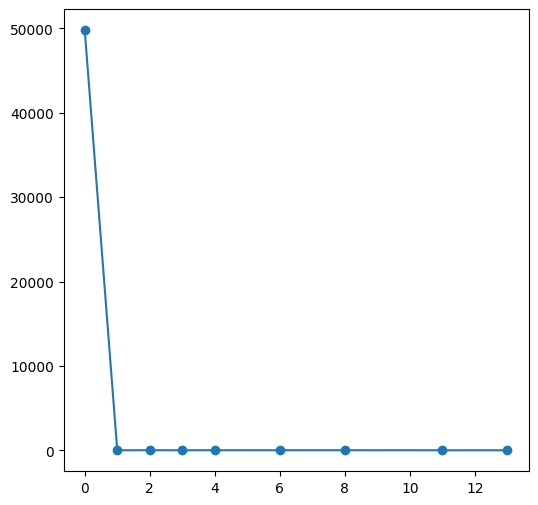

In [188]:
val, freq = np.unique(tn5_insert_freq[sample_empty[0]].toarray(), return_counts=True)

fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.plot(val, freq, marker='o' )#, marker='0', linestyle='None')